# This notebook is meant to test the basic functionality of the engine, including creating blocks, adding parameters, and running a workflow.

Imports

In [1]:
import sys
sys.path.append("..")  # Add parent directory to sys.path to allow imports
from ct_autodiff.engine.block import Block
from ct_autodiff.engine.workflow import Workflow

## Define Example Blocks and Workflow

This section builds a simple trainable polynomial workflow from three blocks:
- `ExampleBlock`: identity pass-through (`x`).
- `ExampleBlock2`: quadratic term (`x + a * x^2`) with learnable parameter `a`.
- `ExampleBlock3`: bias term (`x + c`) with learnable parameter `c`.

When chained in sequence, the workflow can approximate targets of the form:
$y \approx x + a x^2 + c$

The goal is to verify that:
- parameters are registered correctly,
- data flows through each block in order, and
- gradients update `a` and `c` during training.

### This is an example of a workflow that is linear and each block's output gets fed into the next.

###
```text
   x
   |
   |      
   v       
[ExampleBlock]
   |out
   |        
   v   
[ExampleBlock2]
   |out
   |        
   v      
[ExampleBlock3]
   |out
   |        
   v
prediction
```

In [2]:
class ExampleBlock(Block):
    def __init__(self):
        super().__init__()
    
    def execute(self, x):
        return x

class ExampleBlock2(Block):
    def __init__(self):
        super().__init__()
        self.add_param(1.0, symbol="a", trainable=True)
    
    def execute(self, x):
        return x + self.a * x**2
    
class ExampleBlock3(Block):
    def __init__(self):
        super().__init__()
        self.add_param(1.0, symbol="c", trainable=True)

    def execute(self, x):
        return x + self.c
    
class ExampleWorkflow(Workflow):
    def __init__(self):
        super().__init__()
        self.add_block(ExampleBlock())
        self.add_block(ExampleBlock2())
        self.add_block(ExampleBlock3())

# Run and train workflow

ExampleWorkflow:
┌───────────────┐
│ ExampleBlock: │
│               │
└───────────────┘
   │
   ▼
┌─────────────────────────────┐
│ ExampleBlock2:              │
│     a: 1.0 (trainable=True) │
└─────────────────────────────┘
   │
   ▼
┌─────────────────────────────┐
│ ExampleBlock3:              │
│     c: 1.0 (trainable=True) │
└─────────────────────────────┘


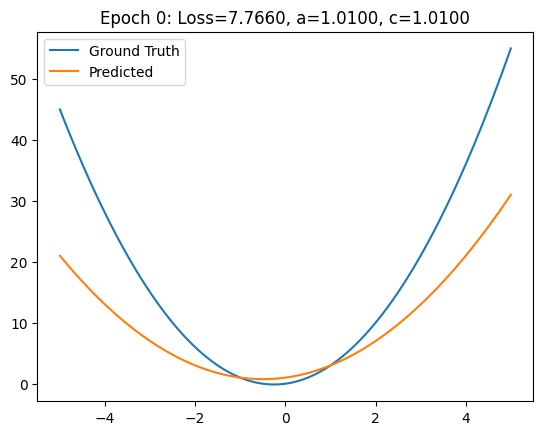

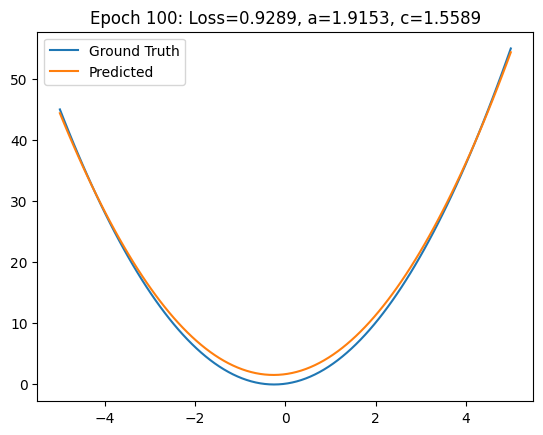

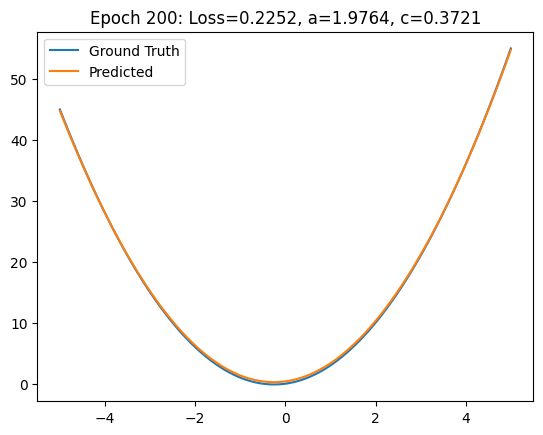

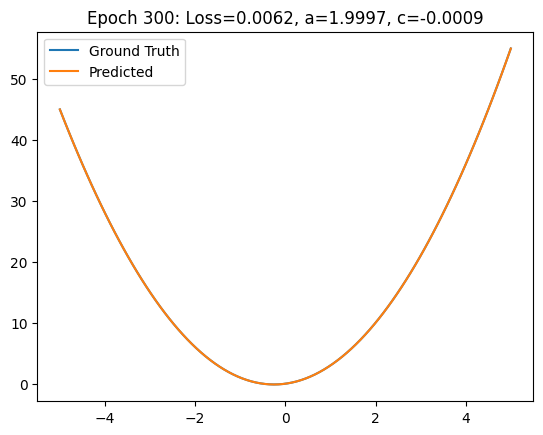

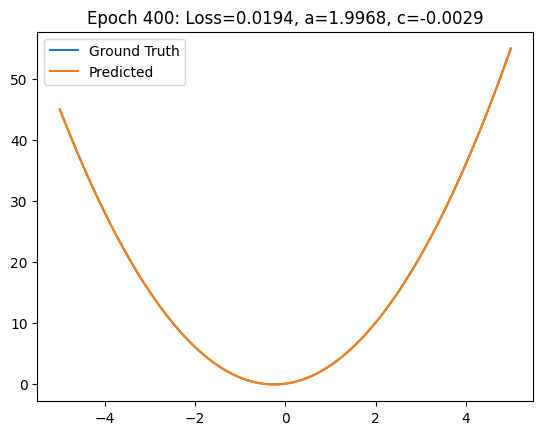

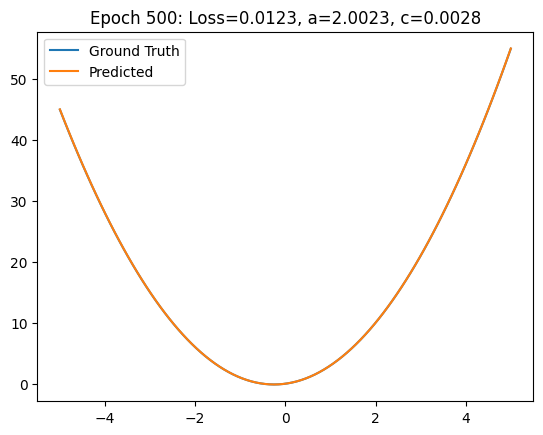

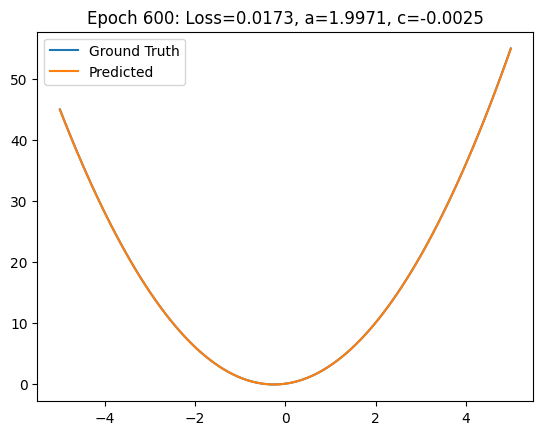

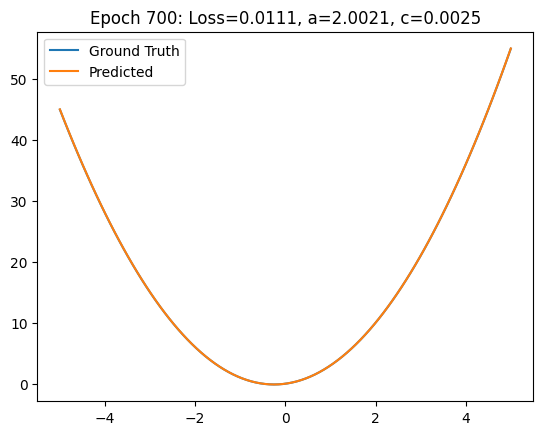

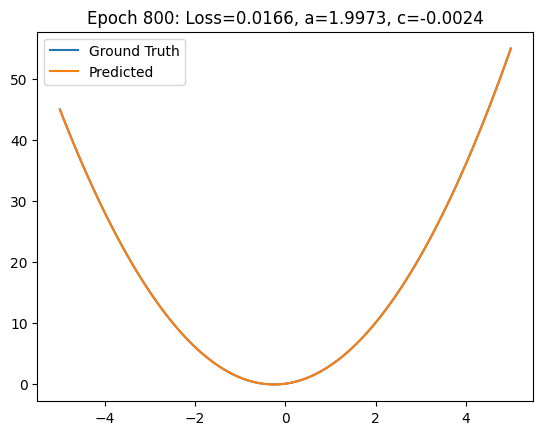

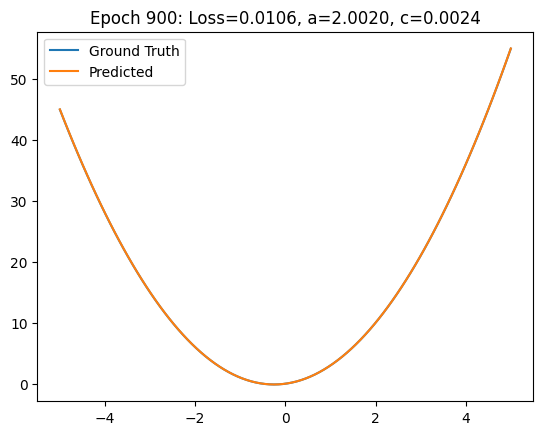

In [3]:
# Generate some test data
import torch
import matplotlib.pyplot as plt

workflow = ExampleWorkflow()
print(workflow)
workflow = workflow.to("cuda" if torch.cuda.is_available() else "cpu")

x = torch.linspace(-5, 5, steps=100)
x = x.to("cuda" if torch.cuda.is_available() else "cpu")
y_gt = 2 * x**2 + x + 0.0

loss_fn = torch.nn.L1Loss()
adam = torch.optim.Adam(workflow.parameters(), lr=0.01)

for epoch in range(1000):
    y_pred = workflow.run(x)
    loss = loss_fn(y_pred, y_gt)
    
    adam.zero_grad()
    loss.backward()
    adam.step()
    
    if epoch % 100 == 0:
        plt.plot(x.cpu(), y_gt.cpu(), label="Ground Truth")
        plt.plot(x.cpu(), y_pred.detach().cpu(), label="Predicted")
        plt.title(f"Epoch {epoch}: Loss={loss.item():.4f}, a={workflow.blocks['ExampleBlock2'].a.item():.4f}, c={workflow.blocks['ExampleBlock3'].c.item():.4f}")
        plt.legend()
        plt.show()

In [4]:
class FirstTerm(Block):
    def __init__(self):
        super().__init__()

    def execute(self, x):
        return x
    

class SecondTerm(Block):
    def __init__(self, scale):
        super().__init__()
        self.add_param(scale, symbol="scale", trainable=True)

    def execute(self, x):
        return self.scale * x**2


class ThirdTerm(Block):
    def __init__(self, offset):
        super().__init__()
        self.add_param(offset, symbol="offset", trainable=True)

    def execute(self):
        return self.offset


class Polynom(Block):
    def __init__(self):
        super().__init__()

    def execute(self, x_sqrt, x, offset):
        return x_sqrt + x + offset


class ExampleDAGWorkflow(Workflow):
    def __init__(self):
        super().__init__()

        self.add_block(SecondTerm(scale=1.0))
        self.add_block(ThirdTerm(offset=1.0))
        self.add_block(FirstTerm())
        self.add_block(Polynom())

    def run(self, x):
        x = self.FirstTerm.execute(x)
        x_sqrt = self.SecondTerm.execute(x)
        offset = self.ThirdTerm.execute()
        return self.Polynom.execute(x_sqrt, x, offset)

    def __str__(self):
        text = "ExampleDAGWorkflow:\n"
        text += """                x
                |\\
                | \\
                |  \\
                |   \\
                |    \\
                |     \\
                |      \\
                |       \\
                |        \\
                |         \\
                |          \\
                |           \\
                |            \\
                |             \\
                |              \\
                |               \\
                v                v
            [FirstTerm]    [SecondTerm]    [ThirdTerm]
                |out             |out            |out
                |                |               |
                |                |               | 
                |                v               |
                +----------> [Polynom] <---------+
                                    |out
                                    |
                                    v
                                prediction"""
        return text

### This is an example of a workflow that is non-linear and has multiple blocks that feed into a final block. The workflow is represented as a directed acyclic graph (DAG) where the nodes are the blocks and the edges represent the flow of data between the blocks. In this example, we have three blocks: `FirstTerm`, `SecondTerm`, and `ThirdTerm`, which all take the same input `x` and produce outputs that are fed into a final block `Polynom` that combines them to produce a prediction.

### Directec Asynchronous Graph
```text
   x
   |\
   | \
   |  \
   |   \
   |    \
   |     \
   |      \
   |       \
   |        \
   |         \
   |          \
   |           \
   |            \
   |             \
   |              \
   |               \
   v                v
[FirstTerm]    [SecondTerm]    [ThirdTerm]
   |out             |out            |out
   |                |               |
   |                |               | 
   |                v               |
   +----------> [Polynom] <---------+
                    |out
                    |
                    v
                prediction
```

ExampleDAGWorkflow:
                x
                |\
                | \
                |  \
                |   \
                |    \
                |     \
                |      \
                |       \
                |        \
                |         \
                |          \
                |           \
                |            \
                |             \
                |              \
                |               \
                v                v
            [FirstTerm]    [SecondTerm]    [ThirdTerm]
                |out             |out            |out
                |                |               |
                |                |               | 
                |                v               |
                +----------> [Polynom] <---------+
                                    |out
                                    |
                                    v
                                prediction


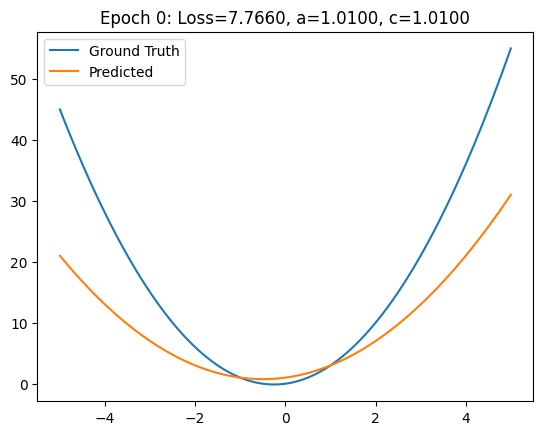

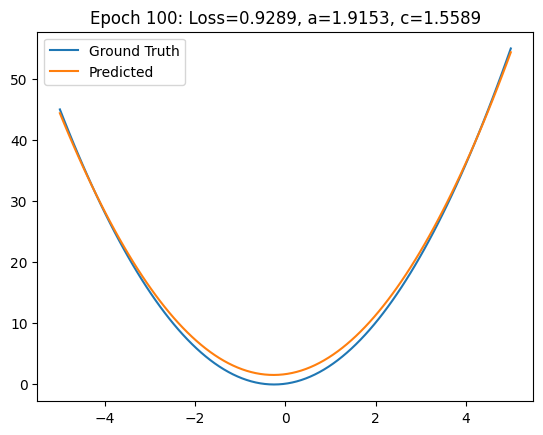

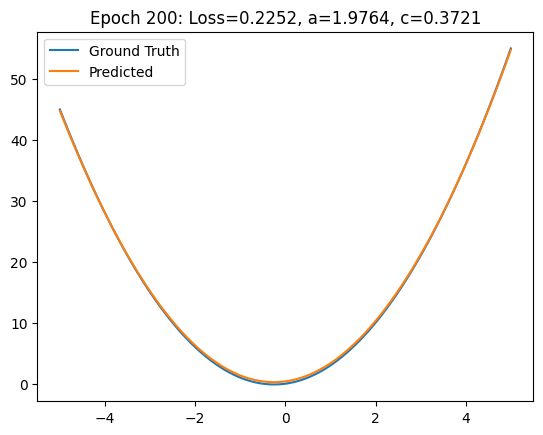

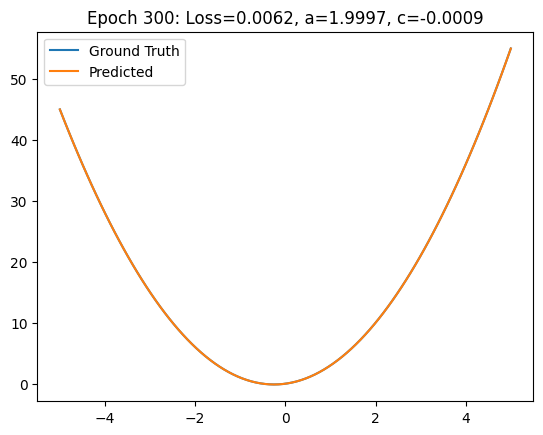

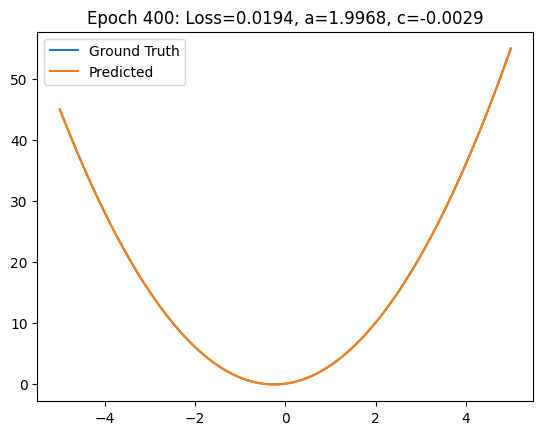

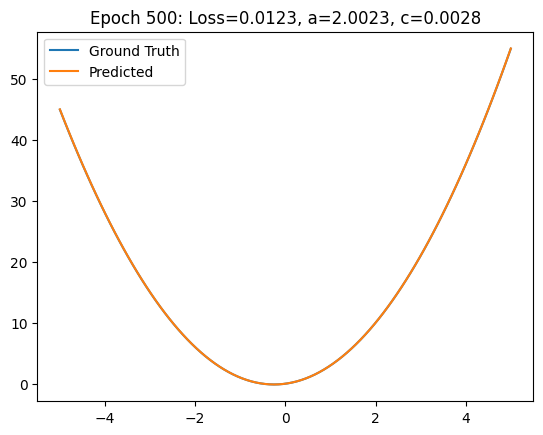

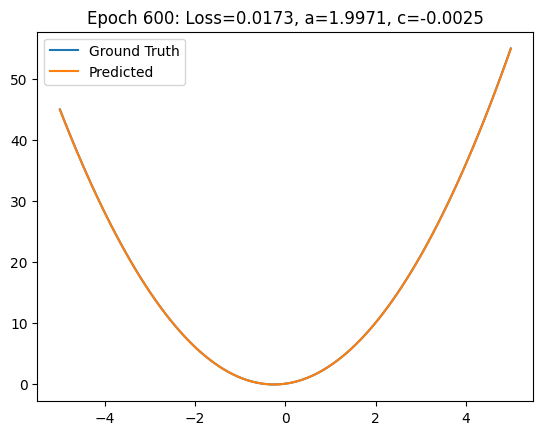

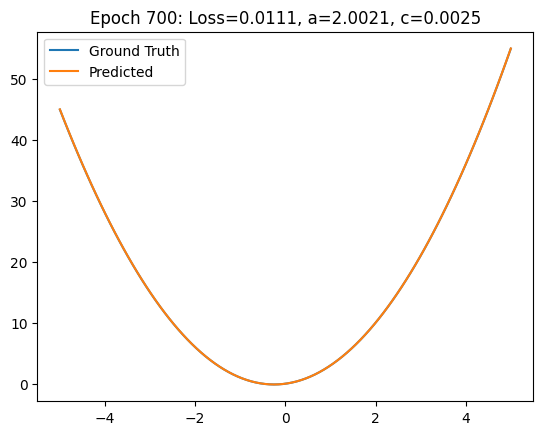

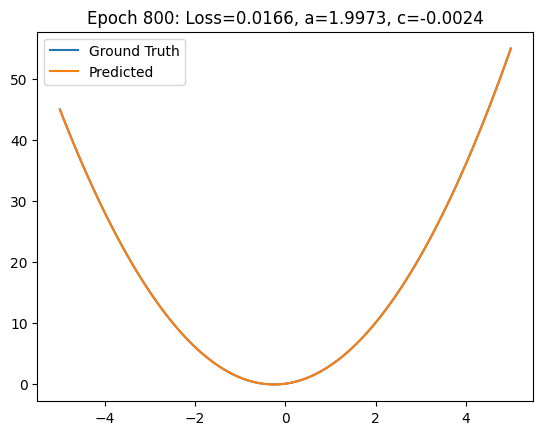

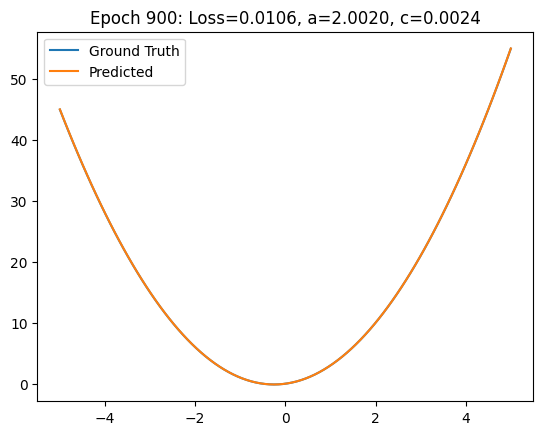

In [5]:
multi_workflow = ExampleDAGWorkflow()
print(multi_workflow)
multi_workflow = multi_workflow.to("cuda" if torch.cuda.is_available() else "cpu")

x = torch.linspace(-5, 5, steps=100)
x = x.to("cuda" if torch.cuda.is_available() else "cpu")
y_gt = 2 * x**2 + x + 0.0

loss_fn = torch.nn.L1Loss()
adam = torch.optim.Adam(multi_workflow.parameters(), lr=0.01)

for epoch in range(1000):
    y_pred = multi_workflow.run(x)
    loss = loss_fn(y_pred, y_gt)
    
    adam.zero_grad()
    loss.backward()
    adam.step()
    
    if epoch % 100 == 0:
        plt.plot(x.cpu(), y_gt.cpu(), label="Ground Truth")
        plt.plot(x.cpu(), y_pred.detach().cpu(), label="Predicted")
        plt.title(
            f"Epoch {epoch}: Loss={loss.item():.4f}, "
            f"a={multi_workflow.blocks['SecondTerm'].scale.item():.4f}, "
            f"c={multi_workflow.blocks['ThirdTerm'].offset.item():.4f}"
        )
        plt.legend()
        plt.show()

## It's nice we get the same result in both cases as it showcases the flexibility of the engine to handle both linear and non-linear workflows. The first workflow demonstrates a simple sequential flow where each block's output feeds directly into the next block, while the second workflow illustrates a more complex DAG structure where multiple blocks feed into a final block that combines their outputs. Both workflows should yield the same prediction if the blocks are designed to compute the same function, confirming that the engine can manage different workflow architectures effectively.